In [27]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit import QuantumRegister, ClassicalRegister, QuantumCircuit 
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
import numpy as np

In [28]:
# Defining registers that store qubits and classical bits for different purposes
def quantum_circuit_estimator():
        """ This function implements an entanglement circuit but specifically for estimator primitives.
            It returns a QuantumCircuit object.
        """
        # Defining attributes of quantum and classical registers
        quantum_reg = QuantumRegister(2, name  = "qubit")
        classical_reg = ClassicalRegister(2, name = "clbit")  # This create a classical regiister object

        # Defining the quantum circuit
        circuit = QuantumCircuit(quantum_reg, classical_reg)
        circuit.h(quantum_reg[0])
        circuit.cx(quantum_reg[0], quantum_reg[1])

        return circuit


In [29]:
def quantum_circuit_sampler(circuit):
        """This function acceps a quantum circuit and measures all qubits on 
        the classical register that is on the circuit it self and reutrn the circuit object.
        """
        circuit = circuit.copy()
        circuit.measure(circuit.qregs[0], circuit.cregs[0])  # This returns a list that is why i used the index 0
        return circuit

Sampler Primitive

In [30]:
sampler = StatevectorSampler()
qcircuit_esti = quantum_circuit_estimator()
qcircuit_samp = quantum_circuit_sampler(qcircuit_esti)
PUB_sam = (qcircuit_samp,)

result_samp = sampler.run([PUB_sam], shots=1000).result()  # Now we have PrimitiveResult object
result_samp_pub = result_samp[0]               # Now we have the PubResult object
data_samp = result_samp_pub.data               # Now we have teh DataBin object
byte_array = data_samp.clbit                   # Now we have the ByteArray object
counts = byte_array.get_counts()               # Now we have the counts dictionary 
print("Counts from Sampler Primitive:", counts)

Counts from Sampler Primitive: {'00': 508, '11': 492}


Estimator Primitive

In [38]:
estimator = StatevectorEstimator()
observable = SparsePauliOp.from_list([("ZZ", 1.0)])  # Defining the observable
PUB_esti = (qcircuit_esti, observable)

result_esti = estimator.run([PUB_esti]).result() # Now we have PrimitiveResult object
result_esti_pub = result_esti[0]                 # Now we have the PubResult object  
data_esti = result_esti_pub.data                 # Now we have the DataBin object
expectation_val = data_esti.evs
print(expectation_val)


0.9999999999999998


In [40]:
import matplotlib.pyplot as plt
import numpy as np

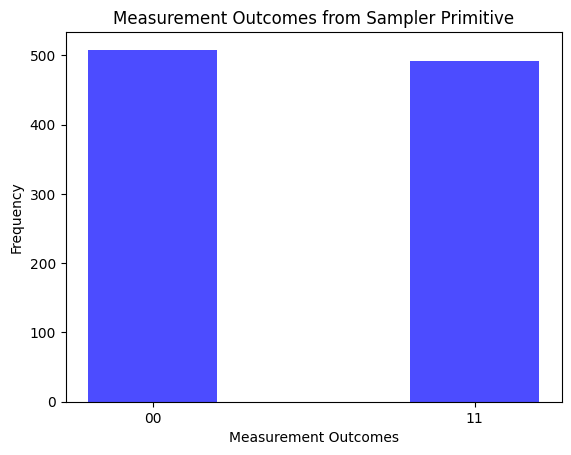

In [42]:
fig, ax = plt.subplots()
ax.bar(counts.keys(), counts.values(), width = 0.4, color = 'blue', alpha = 0.7)
ax.set_xlabel('Measurement Outcomes')
ax.set_ylabel('Frequency')
ax.set_title('Measurement Outcomes from Sampler Primitive')
plt.show()
